# Explorations and Analysis of the ENTSO-E data

In [2]:
# Fix the path 
import sys
import os

sys.path.append(os.path.abspath(".."))  # since you're in src/data_analysis
os.environ["ENTSOE_API_KEY"] = "ec10538b-eae1-4d71-ada6-45feff2e51c2"
os.environ["QUANT_DB_HOST"] = "localhost"
os.environ["QUANT_DB_PORT"] = "15432"
os.environ["QUANT_DB_NAME"] = "options_db"
os.environ["QUANT_DB_USER"] = "quant_user"
os.environ["QUANT_DB_PASSWORD"] = "strong_password"


In [3]:
# import necessary libraries
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Ensure notebook picks up local code edits without kernel restarts
%load_ext autoreload
%autoreload 2

# custom imports
import electricity_price_predictor.entsoe_api as api
import electricity_price_predictor.pipeline as pipeline

importlib.reload(api)
importlib.reload(pipeline)

from electricity_price_predictor.db import get_engine
from electricity_price_predictor.pipeline import run_feature_pipeline


In [4]:
def access_data(
    start: pd.Timestamp,
    end: pd.Timestamp,
    country_code: str,
    history_hours: int = 48,
) -> pd.DataFrame:
    """
    Fetch features for [start, end) while pulling extra lookback history.

    We need lookback because feature generation creates lagged columns (t-1..t-24)
    and drops rows with NaNs.
    """
    api_key = os.getenv("ENTSOE_API_KEY")
    if not api_key:
        raise RuntimeError("ENTSOE_API_KEY environment variable is required.")

    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)
    if start_ts.tz is None:
        start_ts = start_ts.tz_localize("UTC")
    else:
        start_ts = start_ts.tz_convert("UTC")

    if end_ts.tz is None:
        end_ts = end_ts.tz_localize("UTC")
    else:
        end_ts = end_ts.tz_convert("UTC")

    engine = get_engine()
    pipeline_start = start_ts - pd.Timedelta(hours=history_hours)

    features = run_feature_pipeline(
        engine=engine,
        entsoe_api_key=api_key,
        country_code=country_code,
        start=pipeline_start,
        end=end_ts,
        cache_ttl_hours=24,
    )

    # Return only the user-requested interval.
    return features[(features.index >= start_ts) & (features.index < end_ts)]



In [5]:
# Pull the latest 48h window ending at the most recent complete hour.
end = pd.Timestamp.now(tz="UTC").floor("h")
start = end - pd.Timedelta(hours=48)

df_CH = access_data(start, end, "CH", history_hours=72)


# pull German data for comparison 
df_DE = access_data(start, end, "DE_LU", history_hours=72)
# pull French data for comparison 
df_FR = access_data(start, end, "FR", history_hours=72)
# pull Italian data for comparison 
df_IT = access_data(start, end, "IT", history_hours=72)
# pull Austrian data for comparison 
df_AT = access_data(start, end, "AT", history_hours=72)
# pull Spanish data for comparison 
df_ES = access_data(start, end, "ES", history_hours=72)




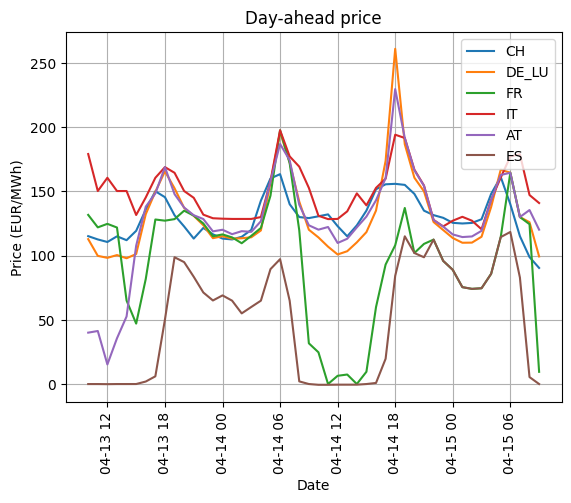

In [6]:
plt.plot(df_CH.index, df_CH["day_ahead_price"], label="CH")
plt.plot(df_DE.index, df_DE["day_ahead_price"], label="DE_LU")
plt.plot(df_FR.index, df_FR["day_ahead_price"], label="FR")
plt.plot(df_IT.index, df_IT["day_ahead_price"], label="IT")
plt.plot(df_AT.index, df_AT["day_ahead_price"], label="AT")
plt.plot(df_ES.index, df_ES["day_ahead_price"], label="ES")

plt.xticks(rotation=90)
plt.grid()
plt.title("Day-ahead price")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()

plt.show()




## Feature engineering 
In the next section we are going to explore which features are justifiable with the given data. 

In [7]:
df_CH.columns

Index(['day_ahead_price', 'load_forecast', 'wind_forecast', 'solar_forecast',
       'residual_load', 'lagged_price_1', 'lagged_residual_load_1',
       'lagged_price_2', 'lagged_residual_load_2', 'lagged_price_3',
       'lagged_residual_load_3', 'lagged_price_4', 'lagged_residual_load_4',
       'lagged_price_5', 'lagged_residual_load_5', 'lagged_price_6',
       'lagged_residual_load_6', 'lagged_price_7', 'lagged_residual_load_7',
       'lagged_price_8', 'lagged_residual_load_8', 'lagged_price_9',
       'lagged_residual_load_9', 'lagged_price_10', 'lagged_residual_load_10',
       'lagged_price_11', 'lagged_residual_load_11', 'lagged_price_12',
       'lagged_residual_load_12', 'lagged_price_13', 'lagged_residual_load_13',
       'lagged_price_14', 'lagged_residual_load_14', 'lagged_price_15',
       'lagged_residual_load_15', 'lagged_price_16', 'lagged_residual_load_16',
       'lagged_price_17', 'lagged_residual_load_17', 'lagged_price_18',
       'lagged_residual_load_18', 'lag

<Axes: >

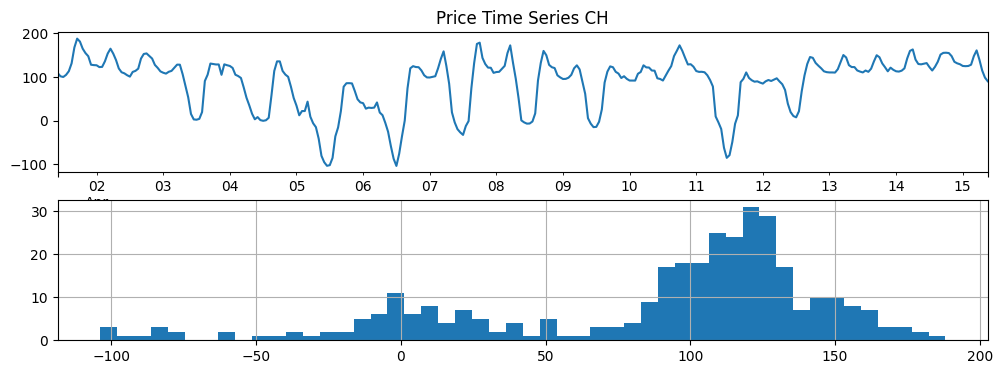

In [8]:
fig, axes = plt.subplots(2,1,figsize=(12,4))
end = pd.Timestamp.now(tz="UTC").floor("h")
start = end - pd.Timedelta(hours=14*24)
df = access_data(start, end, "CH", history_hours=72)
df["day_ahead_price"].plot(ax = axes[0], title = "Price Time Series CH")
df["day_ahead_price"].hist(bins=50, ax = axes[1])

Observations: 

* Intraday seasonality 
* $\mu \approx 125$
* Noise 

An approach could be to model it as 

Price(t) = µ + seasonal(t) + noise

In [ ]:
# Fit an AR(1) process: X_t = c + phi * X_{t-1} + eps_t
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Use existing `ts` if available; otherwise fall back to the day-ahead price series
if "ts" not in locals():
    ts = df["day_ahead_price"]

ts_ar1 = pd.Series(ts).dropna()
if len(ts_ar1) < 3:
    raise ValueError("Not enough observations to fit AR(1).")

x_t = ts_ar1.iloc[1:]
x_lag = ts_ar1.shift(1).iloc[1:]

X = sm.add_constant(x_lag)
ar1_model = sm.OLS(x_t, X).fit()

mu = ar1_model.params["const"]
phi = ar1_model.params[x_lag.name] if x_lag.name in ar1_model.params.index else ar1_model.params.iloc[1]
sigma = float(np.sqrt(ar1_model.mse_resid))

print(f"AR(1) fit complete on {len(x_t)} observations")
print(f"mu (intercept): {mu:.6f}")
print(f"phi (lag-1 coefficient): {phi:.6f}")
print(f"sigma (residual std): {sigma:.6f}")

ar1_model.summary()

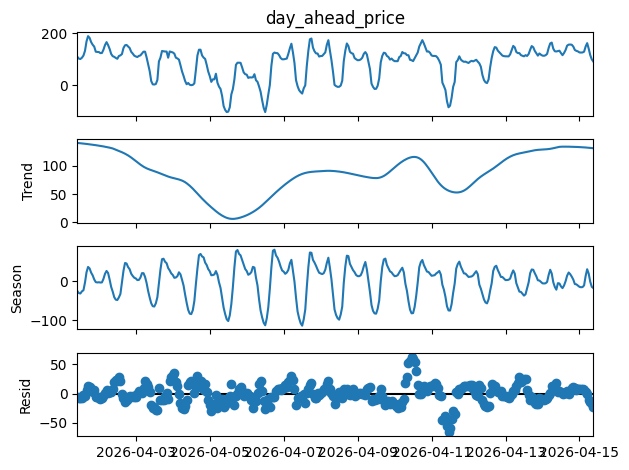

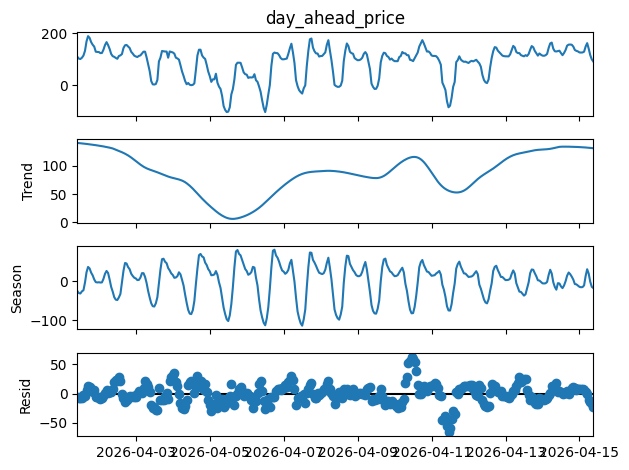

In [10]:
# Let's explore this further with an STL decomposition 
from statsmodels.tsa.seasonal import STL 

ts = df["day_ahead_price"]

stl = STL(ts, period=24)
res = stl.fit()

res.plot()




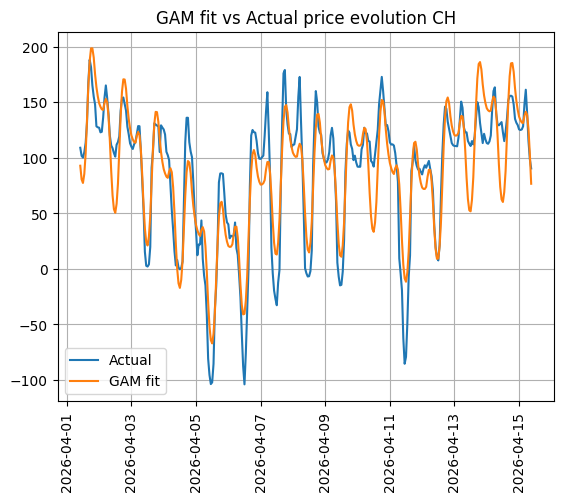

In [17]:
# Model with gam 
df["hour"] = df.index.hour 
df["t"] = range(len(df))

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

from pygam import LinearGAM, s 

X = df[["t", "hour_sin", "hour_cos"]].values
y = df["day_ahead_price"].values 

gam = LinearGAM(s(0) + s(1) + s(2)).fit(X, y)

y_pred = gam.predict(X)

plt.plot(df.index, y, label="Actual")
plt.plot(df.index, y_pred, label="GAM fit")
plt.xticks(rotation = 90)
plt.title("GAM fit vs Actual price evolution CH")
plt.grid()
plt.legend()
plt.show()

To check if this type of model explains the prices well, we check the residuals. 

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     27.3722
Link Function:                     IdentityLink Log Likelihood:                                 -1589.0319
Number of Samples:                          336 AIC:                                             3234.8082
                                                AICc:                                            3240.2438
                                                GCV:                                              952.7259
                                                Scale:                                             28.5328
                                                Pseudo R-Squared:                                   0.7985
Feature Function                  Lam

/var/folders/0r/jb7z1qk9795_hzp0h_jhb31w0000gn/T/ipykernel_22914/2225750900.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


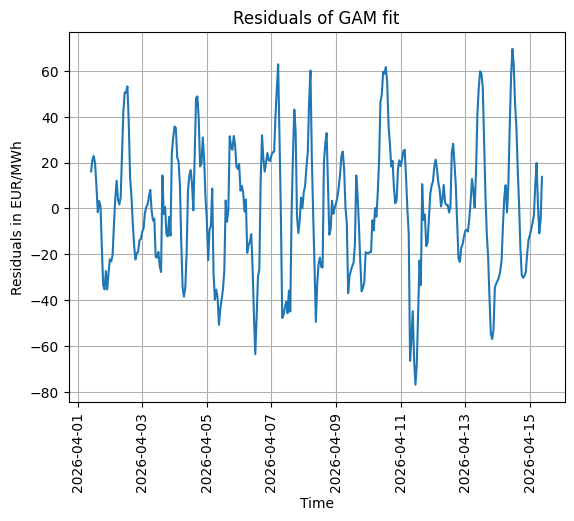

In [26]:
gam.summary()
resid = gam.deviance_residuals(X,y)

plt.plot(df.index, gam.deviance_residuals(X,y))
plt.title("Residuals of GAM fit")
plt.xlabel("Time")
plt.ylabel("Residuals in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.show()





We observe that that the residuals seem to be approximately mean zero and patternless by eye, so the GAM appears to have removed most of the trend and seasonality. But we still need diagnostics for claiming stationarity. 

Mean residual 3.7022165227675766e-09
Std residual 27.3459367978445


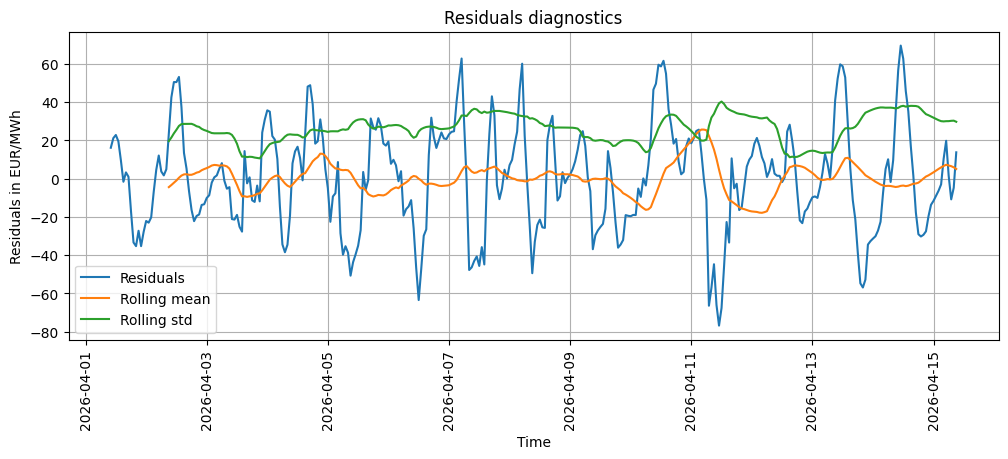

In [28]:
print("Mean residual", resid.mean())
print("Std residual", resid.std())

resid_s = pd.Series(resid, index=df.index)

plt.figure(figsize=(12,4))
plt.plot(resid_s, label="Residuals")
plt.plot(resid_s.rolling(24).mean(), label="Rolling mean")
plt.plot(resid_s.rolling(24).std(), label="Rolling std")
plt.title("Residuals diagnostics")
plt.xlabel("Time")
plt.ylabel("Residuals in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.legend()
plt.show()








Indeed the mean is close to zero and the standard deviation is contained by 40 EUR/MWh. 

Next we have to investigate the autocorrelation structure. 

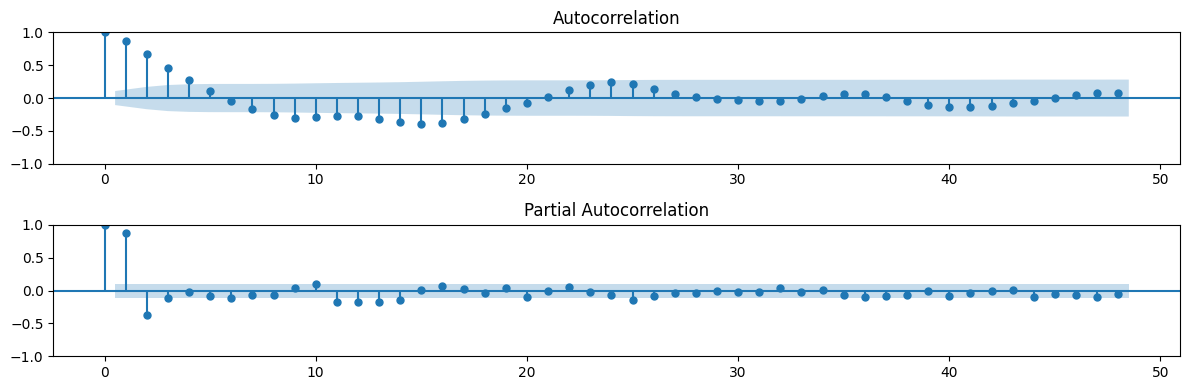

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

fig, ax = plt.subplots(2,1, figsize = (12,4))
plot_acf(resid, lags = 48, ax = ax[0])
plot_pacf(resid, lags = 48, ax = ax[1], method = "ywm")
plt.tight_layout()
plt.show()





One can see large spikes in the autocorrelation for lag 1 - 5 (outside of the confidence band). This means that actually the residuals are not uncorrelated. In fact, they could be modeled with an AR(1) process. 

const   -0.012281
y.L1     0.874311
dtype: float64
AR(1) fit complete on 336 observations
mu (intercept): -0.012281
phi (lag-1 coefficient): 0.874311
sigma (residual std): 13.279484


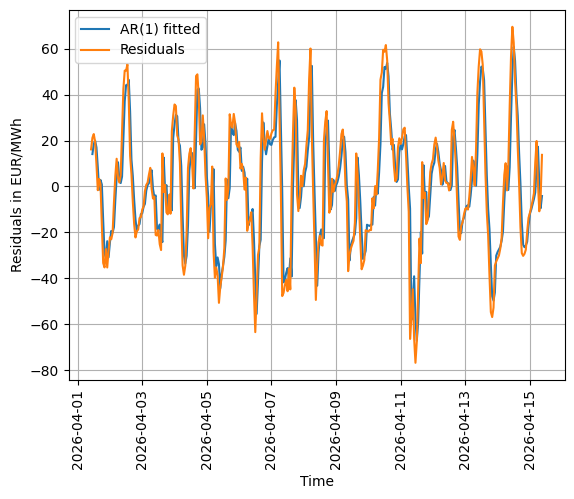

RMSE: 13.2795
MAE:  9.6527


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                      y   No. Observations:                  336
Model:                     AutoReg(1)   Log Likelihood               -1341.728
Method:               Conditional MLE   S.D. of innovations             13.279
Date:                Wed, 15 Apr 2026   AIC                           2689.456
Time:                        16:53:56   BIC                           2700.899
Sample:                    04-01-2026   HQIC                          2694.018
                         - 04-15-2026                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0123      0.726     -0.017      0.986      -1.434       1.410
y.L1           0.8743      0.027     32.990      0.000       0.822       0.926
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.1438           +0.0000j            1.1438            0.0000
-----------------------------------------------------------------------------
"""

In [67]:
# Robust AR(1) fit + visual comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg


# Fit AR(1): X_t = c + phi * X_{t-1} + eps_t
ar1 = AutoReg(resid_s, lags=1, old_names=False).fit()
params = ar1.params
print(params)

mu = float(params["const"])
phi = float(params["y.L1"])
sigma = float(np.sqrt(ar1.sigma2))


print(f"AR(1) fit complete on {len(resid_s.values)} observations")
print(f"mu (intercept): {mu:.6f}")
print(f"phi (lag-1 coefficient): {phi:.6f}")
print(f"sigma (residual std): {sigma:.6f}")

# In-sample one-step-ahead fitted values
fitted = ar1.fittedvalues
aligned_actual = resid_s.loc[fitted.index]


plt.plot(fitted.index, fitted, label = "AR(1) fitted")
plt.plot(resid_s.index, resid_s, label = "Residuals")
plt.xlabel("Time")
plt.ylabel("Residuals in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.legend()
plt.show()




# Quick fit metrics
rmse = float(np.sqrt(np.mean((aligned_actual - fitted) ** 2)))
mae = float(np.mean(np.abs(aligned_actual - fitted)))
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

ar1.summary()

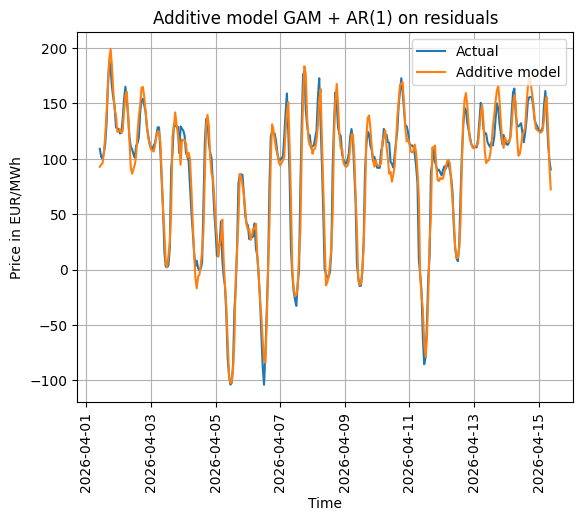

In [75]:
# Now we check if upon additive combination of the two models, we get a good fit. 
additive_model = y_pred + np.insert(ar1.fittedvalues, 0, 0)

plt.plot(df.index, df["day_ahead_price"], label = "Actual")
plt.plot(df.index, additive_model, label = "Additive model")
plt.xlabel("Time")
plt.ylabel("Price in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.title("Additive model GAM + AR(1) on residuals")
plt.legend()
plt.show()



Seemingly this additive model is explaining the time series better than only the GAM. 
# LightGBM Machine Learning model

Previously, we considered a statistical model to explain the data that we are seing. 
Next, we will look into Machine Learning models that do the same, just in a more brute-force way. Their advantage is, that they can use many different features of the available data to model the price prediction. 

Crucially, the electrity price non-linearly depends on exogenous variables like the weather (features: wind forecast, solar forecast, ...). Thus, it is a good idea to use non-linear, superwised Machine Learning models. In that most prominently lie the Boosting of decision trees, in particular one of the most efficient algorithms among them is LightGBM. 

In [78]:
# Split the data into target_col and feature_cols
import numpy as np
import pandas as pd

target_col = "day_ahead_price"
feature_cols = [col for col in df.columns if col != target_col]

# LightGBM requires numeric dtypes. Coerce object columns and drop rows that become NaN.
df_model = df[feature_cols + [target_col]].copy()
df_model[feature_cols + [target_col]] = df_model[feature_cols + [target_col]].apply(
    pd.to_numeric,
    errors="coerce"
)
df_model = df_model.dropna().copy()

if df_model.empty:
    raise ValueError("No rows left after numeric coercion and NaN removal.")

# Split the data into training, validation and test set
n = len(df_model)
train_end = int(n * 0.7)
valid_end = int(n * 0.85)

train = df_model.iloc[:train_end]
valid = df_model.iloc[train_end:valid_end]
test = df_model.iloc[valid_end:]

# Define the feature matrices and target vectors
X_train = train[feature_cols]
y_train = train[target_col]
X_valid = valid[feature_cols]
y_valid = valid[target_col]
X_test = test[feature_cols]
y_test = test[target_col]

# Sanity check: all feature columns must be numeric for LightGBM
non_numeric_cols = X_train.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
if non_numeric_cols:
    raise ValueError(f"Non-numeric columns found in training data: {non_numeric_cols}")

# Define the LightGBM model
import lightgbm as lgb
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=1,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l1"
)

# Predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

valid_pred = model.predict(X_valid)
test_pred = model.predict(X_test)

print("Validation MAE:", mean_absolute_error(y_valid, valid_pred))
print("Validation RMSE:", rmse(y_valid, valid_pred))

print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Test RMSE:", rmse(y_test, test_pred))

# Benchmark against naive model
naive_pred = test["lagged_price_24"]

print("Naive MAE:", mean_absolute_error(y_test, naive_pred))
print("Naive RMSE:", rmse(y_test, naive_pred))


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: load_forecast: object, wind_forecast: object, solar_forecast: object, residual_load: object, lagged_price_1: object, lagged_residual_load_1: object, lagged_price_2: object, lagged_residual_load_2: object, lagged_price_3: object, lagged_residual_load_3: object, lagged_price_4: object, lagged_residual_load_4: object, lagged_price_5: object, lagged_residual_load_5: object, lagged_price_6: object, lagged_residual_load_6: object, lagged_price_7: object, lagged_residual_load_7: object, lagged_price_8: object, lagged_residual_load_8: object, lagged_price_9: object, lagged_residual_load_9: object, lagged_price_10: object, lagged_residual_load_10: object, lagged_price_11: object, lagged_residual_load_11: object, lagged_price_12: object, lagged_residual_load_12: object, lagged_price_13: object, lagged_residual_load_13: object, lagged_price_14: object, lagged_residual_load_14: object, lagged_price_15: object, lag